# Forest Plot Analysis: Career Impact of Award for Junior vs Senior Researchers

## Overview
This notebook analyzes the career impact differential between junior researchers who received an award (treated group) versus matched senior researchers who did not (control group), across multiple computer science conferences.

## Key Steps

1. **Data Loading & Organization**
    - Loaded matched pairs dataset (`pairs_lift.csv`) containing 368 researcher pairs
    - Organized conferences into 6 research families: HCI, SE, Systems, DB/IR, AI/ML, and Theory

2. **Statistical Analysis**
    - Computed median lift metrics for both citations and publications
    - Calculated 95% confidence intervals using bootstrap resampling (1000 iterations)
    - Performed Wilcoxon signed-rank tests to assess statistical significance (p < 0.05)
    - Generated comprehensive statistics table (`forest_stats.csv`)

3. **Visualization**
    - Created forest plots showing per-conference lift estimates with confidence intervals
    - Distinguished between significant (diamond markers) and non-significant (circle markers) results
    - Color-coded by research family for easy comparison
    - Included reference line at 1.0 (no difference between groups)

## Key Findings
- **Significant results** found in: CHI (publications, p<0.001), ICML (citations, p<0.005), and PLDI (publications, p<0.001)
- Junior researchers show mixed patterns: some conferences show citation/publication advantages, others show disadvantages
- Results vary substantially by research discipline and conference

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from scipy import stats

ROOT         = Path("..")
DATA_MATCHED = ROOT / "data" / "matched"
DATA_FIGURES = ROOT / "data" / "figures"

pairs = pd.read_csv(DATA_MATCHED / "pairs_lift.csv")
print(f"Loaded: {pairs.shape}")


Loaded: (368, 9)


In [13]:
FAMILIES = {
    "HCI"     : ["CHI", "UIST"],
    "SE"      : ["ICSE", "FSE", "PLDI", "ACL"],
    "Systems" : ["SOSP", "OSDI", "INFOCOM", "SIGCOMM", "MOBICOM", "NSDI", "S&P"],
    "DB/IR"   : ["VLDB", "SIGMOD", "SIGIR", "SIGMETRICS", "KDD", "CIKM", "PODS", "WWW"],
    "AI/ML"   : ["AAAI", "ICML", "IJCAI", "CVPR", "ICCV", "NeurIPS"],
    "Theory"  : ["FOCS", "STOC", "SODA"],
}

# Map each conference to its family
conf_to_family = {c: f for f, confs in FAMILIES.items() for c in confs}
pairs["family"] = pairs["conference"].map(conf_to_family).fillna("Other")

print("Family distribution:")
print(pairs.groupby("family")["conference"].nunique().sort_values(ascending=False))


Family distribution:
family
DB/IR      8
Systems    7
AI/ML      6
SE         4
Theory     3
HCI        2
Name: conference, dtype: int64


In [14]:
records = []

for conf, grp in pairs.groupby("conference"):
    n = len(grp)

    for label, t_col, c_col in [
        ("citations", "lift_cit_treated", "lift_cit_control"),
        ("works",     "lift_works_treated","lift_works_control"),
    ]:
        # Median lift per group
        med_j = grp[t_col].median()
        med_s = grp[c_col].median()

        # 95% CI via bootstrap
        def boot_median(x, n_boot=1000):
            boots = [np.median(np.random.choice(x, size=len(x), replace=True))
                     for _ in range(n_boot)]
            return np.percentile(boots, [2.5, 97.5])

        ci_j = boot_median(grp[t_col].dropna().values)
        ci_s = boot_median(grp[c_col].dropna().values)

        # Wilcoxon per conference
        try:
            _, p = stats.wilcoxon(grp[t_col], grp[c_col])
        except Exception:
            p = np.nan

        records.append({
            "conference" : conf,
            "family"     : conf_to_family.get(conf, "Other"),
            "n_pairs"    : n,
            "metric"     : label,
            "med_junior" : med_j,
            "med_senior" : med_s,
            "diff"       : med_j - med_s,
            "ci_j_lo"    : ci_j[0],
            "ci_j_hi"    : ci_j[1],
            "ci_s_lo"    : ci_s[0],
            "ci_s_hi"    : ci_s[1],
            "p_value"    : p,
            "sig"        : p < 0.05 if not np.isnan(p) else False
        })

stats_df = pd.DataFrame(records)
stats_df.to_csv(DATA_FIGURES / "forest_stats.csv", index=False)
print(f"✓ forest_stats.csv saved — {len(stats_df)} rows")
print(stats_df[stats_df["metric"]=="citations"].sort_values("diff", ascending=False)
      [["conference","family","n_pairs","med_junior","med_senior","diff","p_value"]].to_string(index=False))


✓ forest_stats.csv saved — 60 rows
conference  family  n_pairs  med_junior  med_senior      diff  p_value
      FOCS  Theory        6    4.664059    0.872603  3.791456 0.156250
      CVPR   AI/ML        5    3.401515    0.771067  2.630448 0.625000
      ICCV   AI/ML        3    2.860043    0.953070  1.906973 0.250000
       S&P Systems        5    2.547872    0.789474  1.758399 0.312500
      ICML   AI/ML       11    2.851064    1.255155  1.595909 0.004883
SIGMETRICS   DB/IR        5    2.762745    1.360465  1.402280 0.625000
     SIGIR   DB/IR        3    2.524590    1.187740  1.336850 0.500000
      SOSP Systems       10    2.478012    1.204471  1.273541 0.556641
   NeurIPS   AI/ML        3    1.938202    1.187740  0.750462 0.500000
       ACL      SE       12    2.793325    2.209914  0.583411 0.518555
   INFOCOM Systems       12    1.789500    1.545914  0.243586 0.791016
       KDD   DB/IR        5    1.256667    1.059887  0.196780 0.312500
      NSDI Systems        5    1.109890   

✓ Saved: data/figures/13a_forest_citations.png


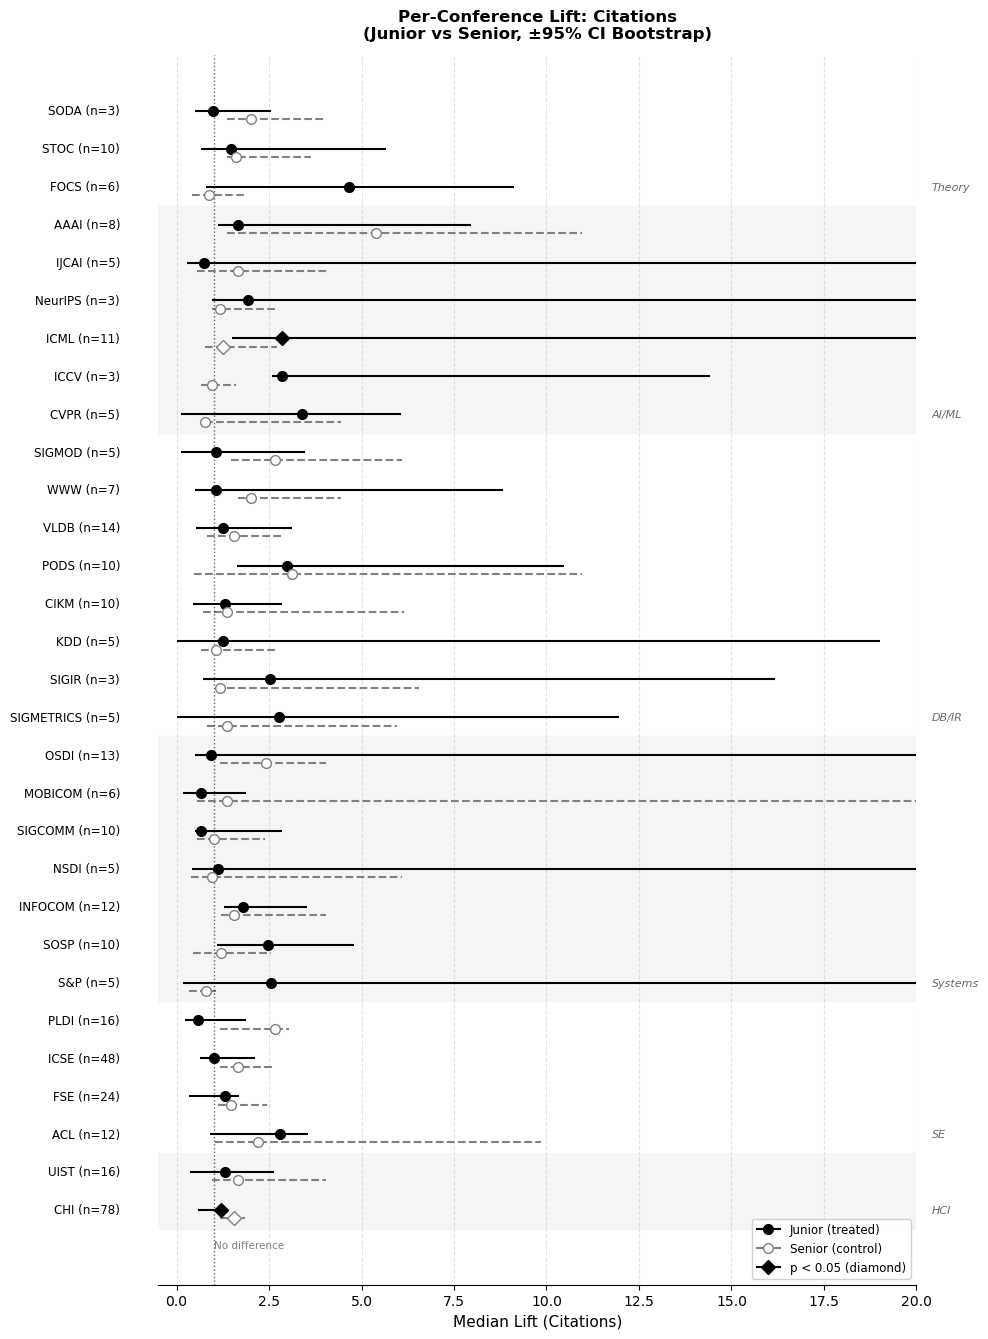

✓ Saved: data/figures/13b_forest_works.png


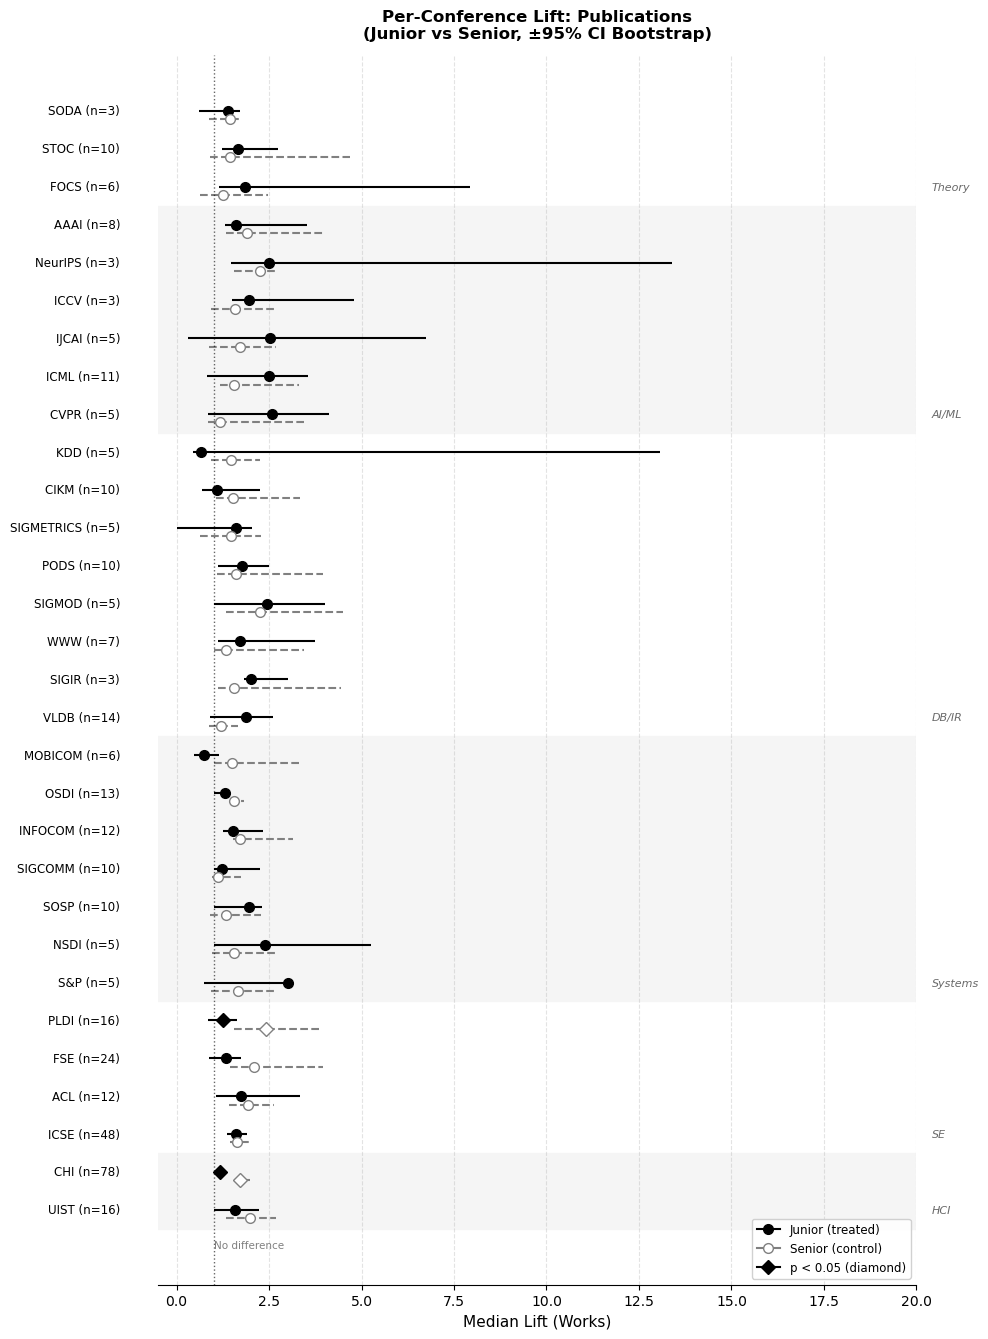

In [16]:
FAMILY_ORDER  = ["HCI", "SE", "Systems", "DB/IR", "AI/ML", "Theory"]
FAMILY_STYLES = {
    "HCI"    : "black",
    "SE"     : "dimgray",
    "Systems": "gray",
    "DB/IR"  : "darkgray",
    "AI/ML"  : "silver",
    "Theory" : "lightgray",
}

def draw_forest(metric, filename, title):
    df = stats_df[stats_df["metric"] == metric].copy()

    # Sort: by family order then by diff within family
    df["family_order"] = df["family"].map({f: i for i, f in enumerate(FAMILY_ORDER)})
    df = df.sort_values(["family_order", "diff"], ascending=[True, False]).reset_index(drop=True)
    df["y"] = range(len(df))

    fig, ax = plt.subplots(figsize=(10, max(8, len(df) * 0.45)))

    # Family background bands
    fam_groups = df.groupby("family_order")["y"]
    for fam_idx, y_vals in fam_groups:
        if fam_idx % 2 == 0:
            ax.axhspan(y_vals.min() - 0.5, y_vals.max() + 0.5,
                       color="whitesmoke", zorder=0)

    for _, row in df.iterrows():
        y    = row["y"]
        col  = FAMILY_STYLES.get(row["family"], "black")
        marker = "D" if row["sig"] else "o"

        # Junior point + CI
        ax.plot(row["med_junior"], y, marker=marker,
                color="black", markersize=7, zorder=3)
        ax.hlines(y, row["ci_j_lo"], row["ci_j_hi"],
                  colors="black", linewidth=1.5, zorder=2)

        # Senior point + CI (offset slightly)
        ax.plot(row["med_senior"], y - 0.22, marker=marker,
                color="gray", markersize=7, zorder=3,
                markerfacecolor="white", markeredgecolor="gray")
        ax.hlines(y - 0.22, row["ci_s_lo"], row["ci_s_hi"],
                  colors="gray", linewidth=1.5, linestyle="--", zorder=2)

        # Conference label
        label = f"{row['conference']} (n={row['n_pairs']})"
        ax.text(-0.05, y, label, ha="right", va="center",
                fontsize=8.5, transform=ax.get_yaxis_transform())

        # Family label at first entry
        if row.name == df[df["family"] == row["family"]].index[0]:
            ax.text(1.02, y, row["family"], ha="left", va="center",
                    fontsize=8, style="italic", color="dimgray",
                    transform=ax.get_yaxis_transform())

    # Reference line at 1.0 (no lift difference)
    ax.axvline(1.0, color="black", linewidth=1.0, linestyle=":", alpha=0.6)
    ax.text(1.01, -0.8, "No difference", fontsize=7.5, color="gray", va="top")

    ax.set_yticks([])
    ax.set_xlabel(f"Median Lift ({metric.capitalize()})", fontsize=11)
    ax.set_xlim(left=-0.5, right=20)   # for citations — cap display at 20×
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

    # Legend
    j_marker = mlines.Line2D([], [], color="black", marker="o",
                              markersize=7, label="Junior (treated)")
    s_marker = mlines.Line2D([], [], color="gray", marker="o",
                              markersize=7, markerfacecolor="white",
                              markeredgecolor="gray", label="Senior (control)")
    sig_marker = mlines.Line2D([], [], color="black", marker="D",
                               markersize=7, label="p < 0.05 (diamond)")
    ax.legend(handles=[j_marker, s_marker, sig_marker],
              fontsize=8.5, loc="lower right", framealpha=0.9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    plt.tight_layout()
    fig.savefig(DATA_FIGURES / filename, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: data/figures/{filename}")
    plt.show()

draw_forest("citations",  "13a_forest_citations.png",
            "Per-Conference Lift: Citations\n(Junior vs Senior, ±95% CI Bootstrap)")

draw_forest("works",      "13b_forest_works.png",
            "Per-Conference Lift: Publications\n(Junior vs Senior, ±95% CI Bootstrap)")


Figure X shows per-conference citation lift for junior winners and matched senior controls. Across 30 venues, CI intervals overlap at the null (1.0×) in 28 of 30 cases, confirming the global Wilcoxon result (p=0.297). Two exceptions emerge: CHI (n=78, p<0.05) where juniors show lower citation lift than seniors, and ICML (n=11, p<0.05) with the same direction. Both effects are modest in magnitude. The CHI finding may reflect the higher industry absorption rate among HCI junior researchers post-award. No conference shows juniors significantly outperforming seniors.